# Predictive Maintenance — AI4I 2020 Dataset

## Overview
Development of a Machine Learning model to predict industrial equipment failure
based on sensor data. The project includes a complete ML pipeline with
feature engineering, hyperparameter tuning via Optuna, and explainability via SHAP.

## Dataset
- **Source:** UCI Machine Learning Repository — AI4I 2020 Predictive Maintenance Dataset
- **Size:** 10,000 observations, 14 features
- **Problem:** Binary classification (Normal / Machine Failure)
- **Class imbalance:** 96.6% Normal, 3.4% Failure

## Results
| Metric | Value |
|--------|-------|
| F1-Score (Failure) | 0.86 |
| Precision (Failure) | 0.88 |
| Recall (Failure) | 0.84 |
| False Alarms | 8 |
| Missed Failures | 11 |

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_curve
from xgboost import XGBClassifier
import optuna
import shap
import joblib
import os

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style("whitegrid")

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


## 2. Data Loading & First Look

In [2]:
df = pd.read_csv('ai4i+2020+predictive+maintenance+dataset/ai4i2020.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nClass distribution:")
print(df['Machine failure'].value_counts())
print(f"\nFailure rate: {df['Machine failure'].mean():.1%}")

df.head()

Dataset shape: (10000, 14)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Missing values: 0

Class distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.4%


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Basic Statistics

In [3]:
df[['Air temperature [K]', 'Process temperature [K]', 
    'Rotational speed [rpm]', 'Torque [Nm]', 
    'Tool wear [min]']].describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


### 3.2 Class Imbalance

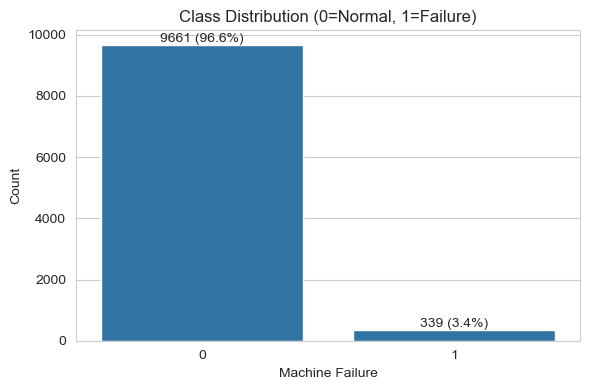

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='Machine failure', ax=ax)
ax.set_title('Class Distribution (0=Normal, 1=Failure)')
ax.set_xlabel('Machine Failure')
ax.set_ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df):.1%})',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

### 3.3 Feature Distributions by Failure

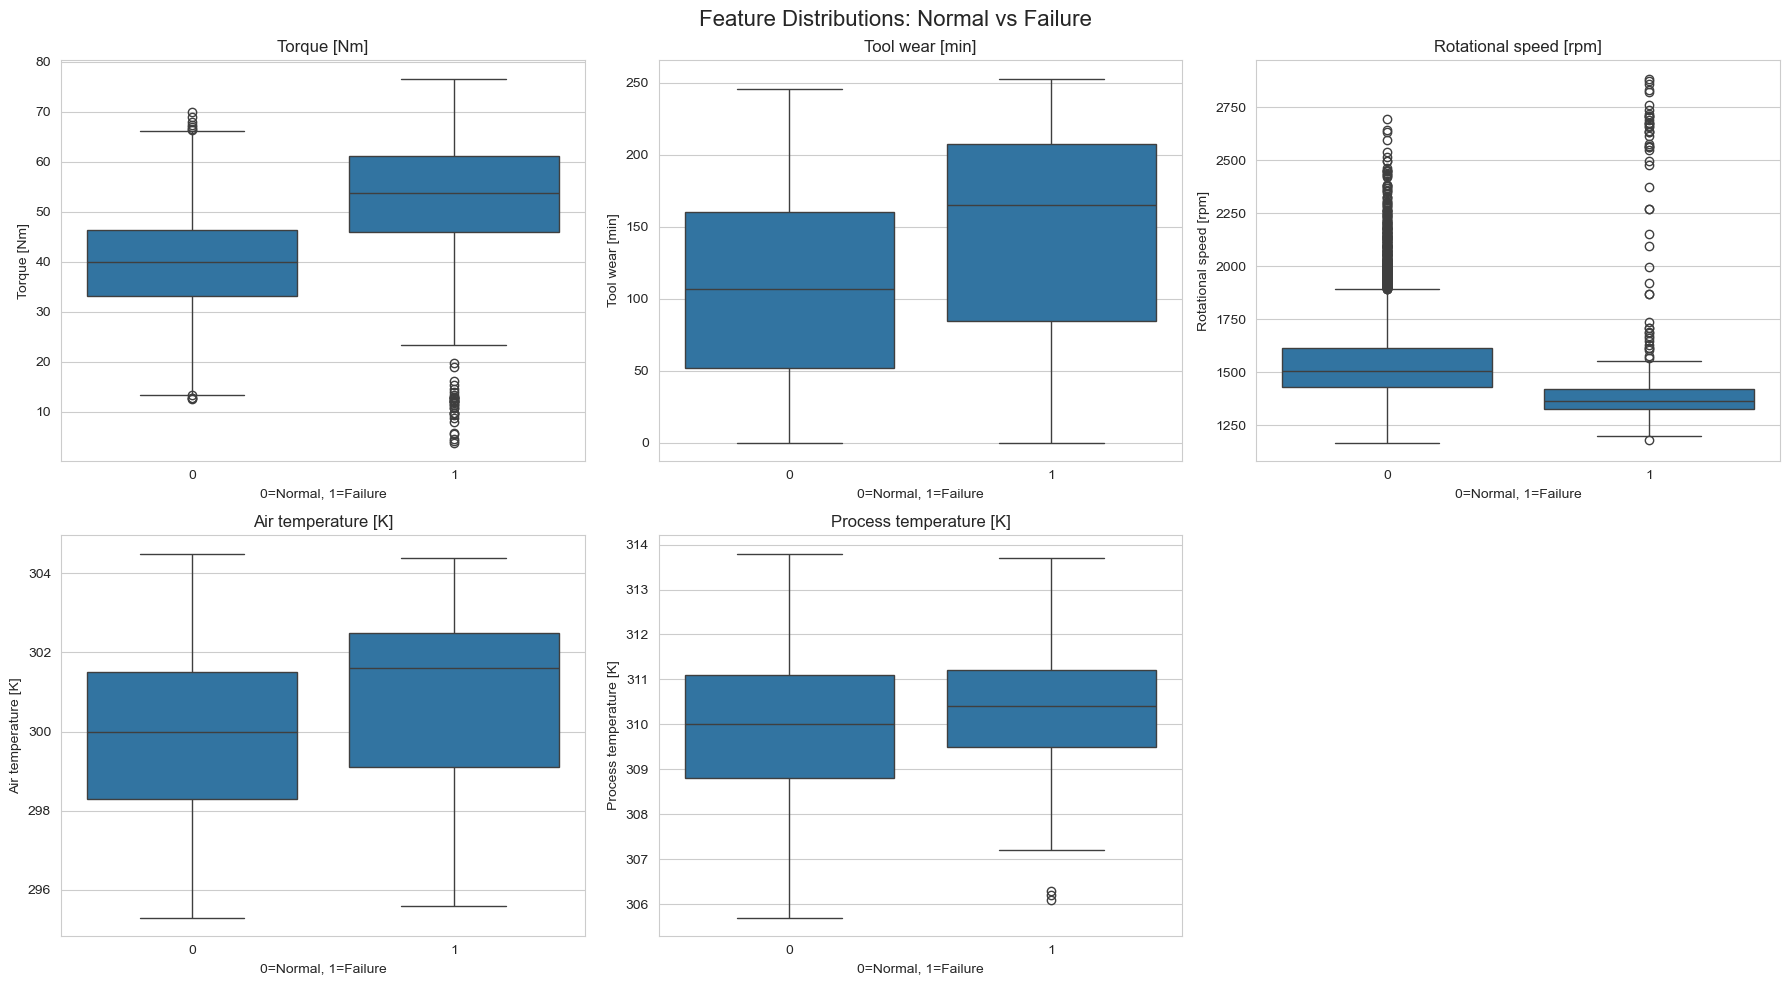

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Feature Distributions: Normal vs Failure', fontsize=16)

features_to_plot = ['Torque [Nm]', 'Tool wear [min]', 
                    'Rotational speed [rpm]', 'Air temperature [K]',
                    'Process temperature [K]']

for i, feature in enumerate(features_to_plot):
    row = i // 3
    col = i % 3
    sns.boxplot(data=df, x='Machine failure', y=feature, ax=axes[row, col])
    axes[row, col].set_title(feature)
    axes[row, col].set_xlabel('0=Normal, 1=Failure')

axes[1, 2].set_visible(False)
plt.tight_layout()
plt.show()

### 3.4 Correlation Analysis

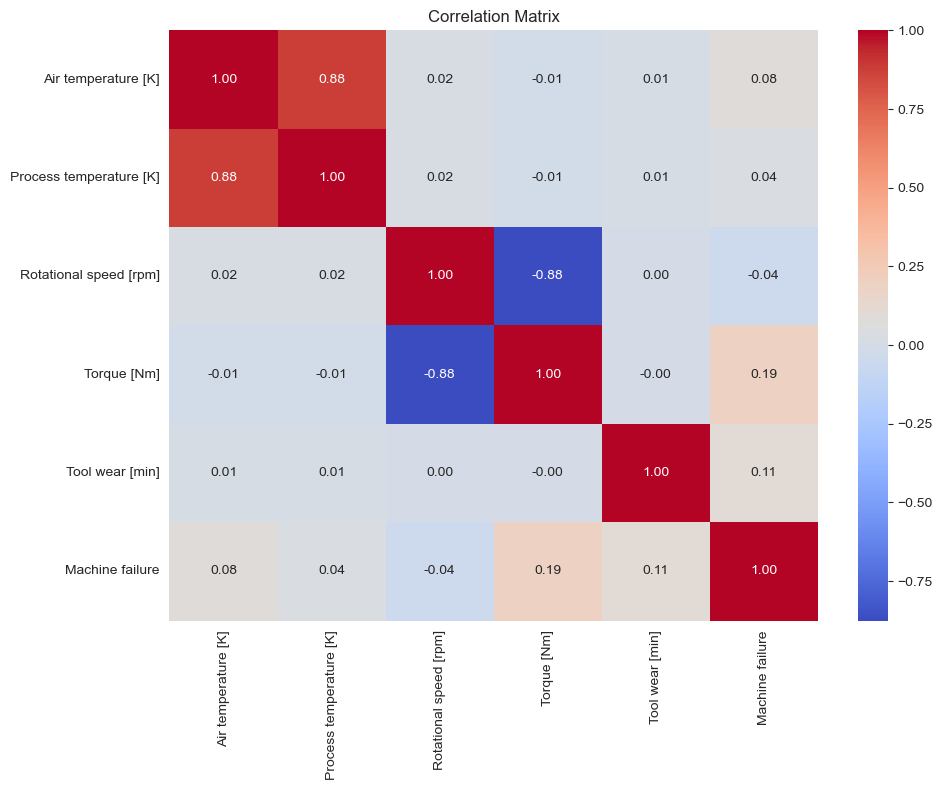

Top correlations with Machine failure:
Machine failure            1.000000
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64


In [6]:
corr_cols = ['Air temperature [K]', 'Process temperature [K]', 
             'Rotational speed [rpm]', 'Torque [Nm]', 
             'Tool wear [min]', 'Machine failure']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

print("Top correlations with Machine failure:")
print(df[corr_cols].corr()['Machine failure'].sort_values(ascending=False))

### 3.5 Failure Type Analysis

Each machine failure can be attributed to one of 5 failure modes:
- **TWF** (Tool Wear Failure): excessive tool wear
- **HDF** (Heat Dissipation Failure): insufficient cooling
- **PWF** (Power Failure): extreme power values
- **OSF** (Overstrain Failure): excessive mechanical load
- **RNF** (Random Failure): no specific cause

In [7]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

print("Failure type distribution:")
for ft in failure_types:
    count = df[ft].sum()
    perc = (count / len(df)) * 100
    print(f"  {ft}: {count} incidents ({perc:.3f}%)")

print(f"\nTotal failures (Machine failure): {df['Machine failure'].sum()}")
print("Note: some failures have multiple concurrent failure modes.")

Failure type distribution:
  TWF: 46 incidents (0.460%)
  HDF: 115 incidents (1.150%)
  PWF: 95 incidents (0.950%)
  OSF: 98 incidents (0.980%)
  RNF: 19 incidents (0.190%)

Total failures (Machine failure): 339
Note: some failures have multiple concurrent failure modes.


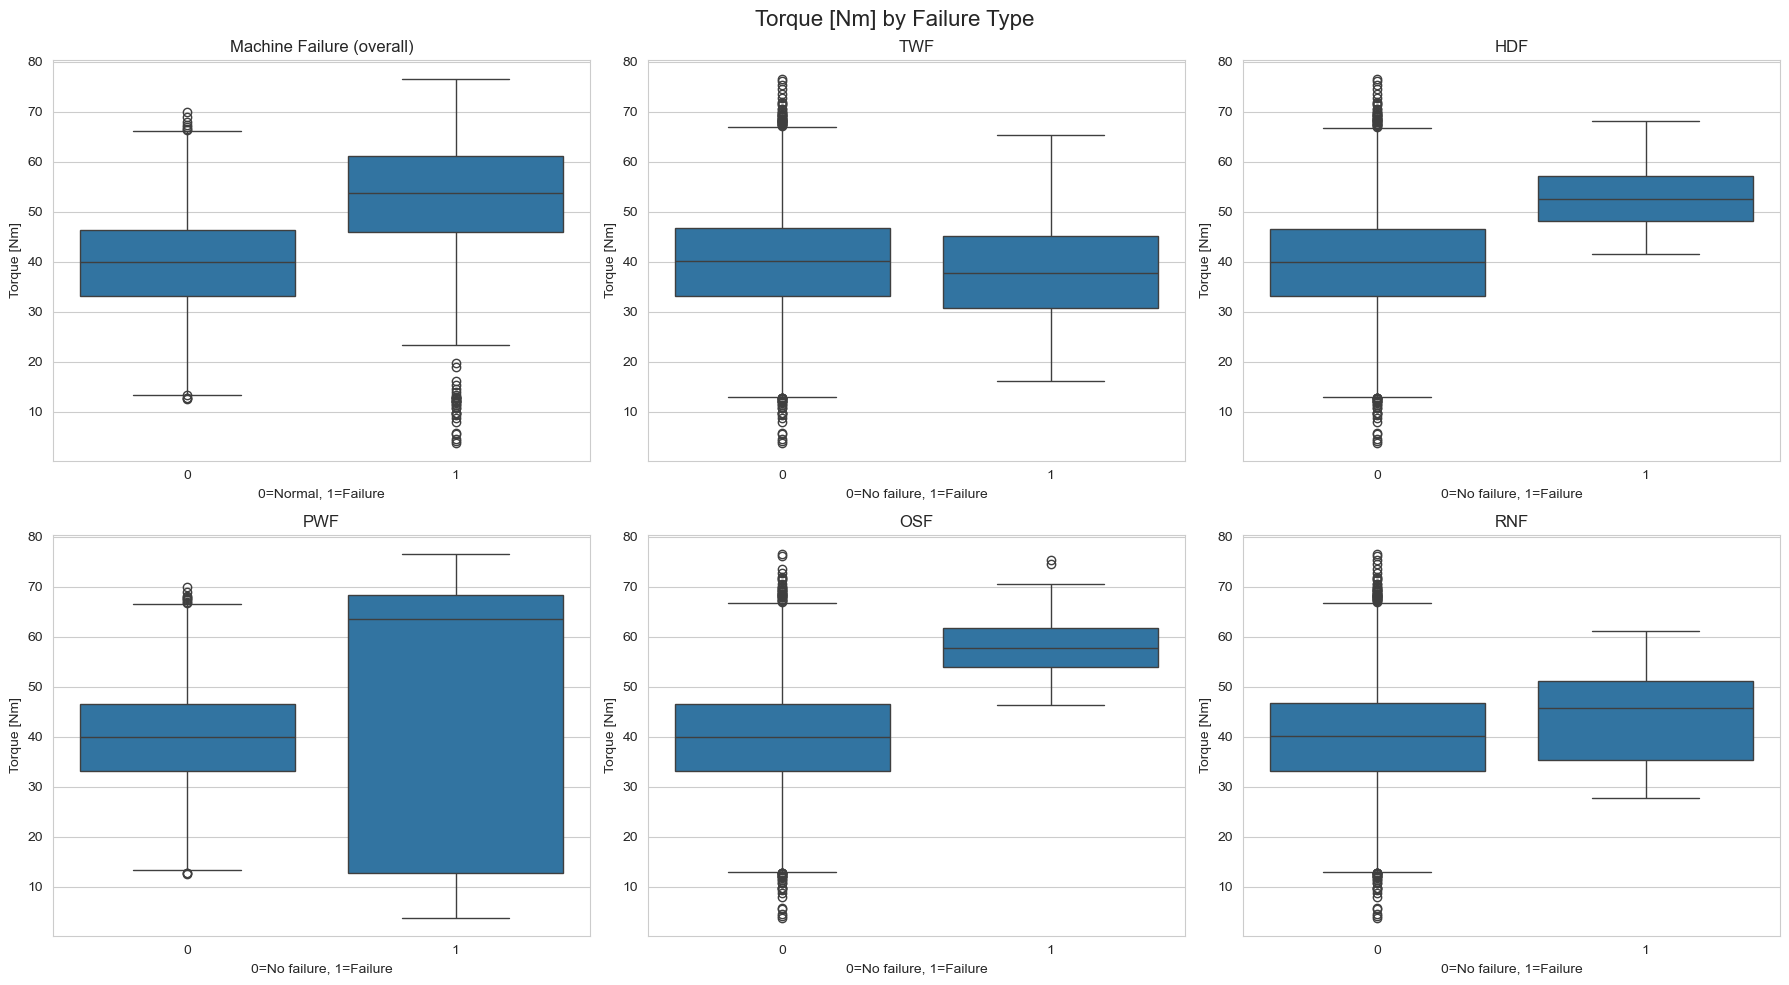

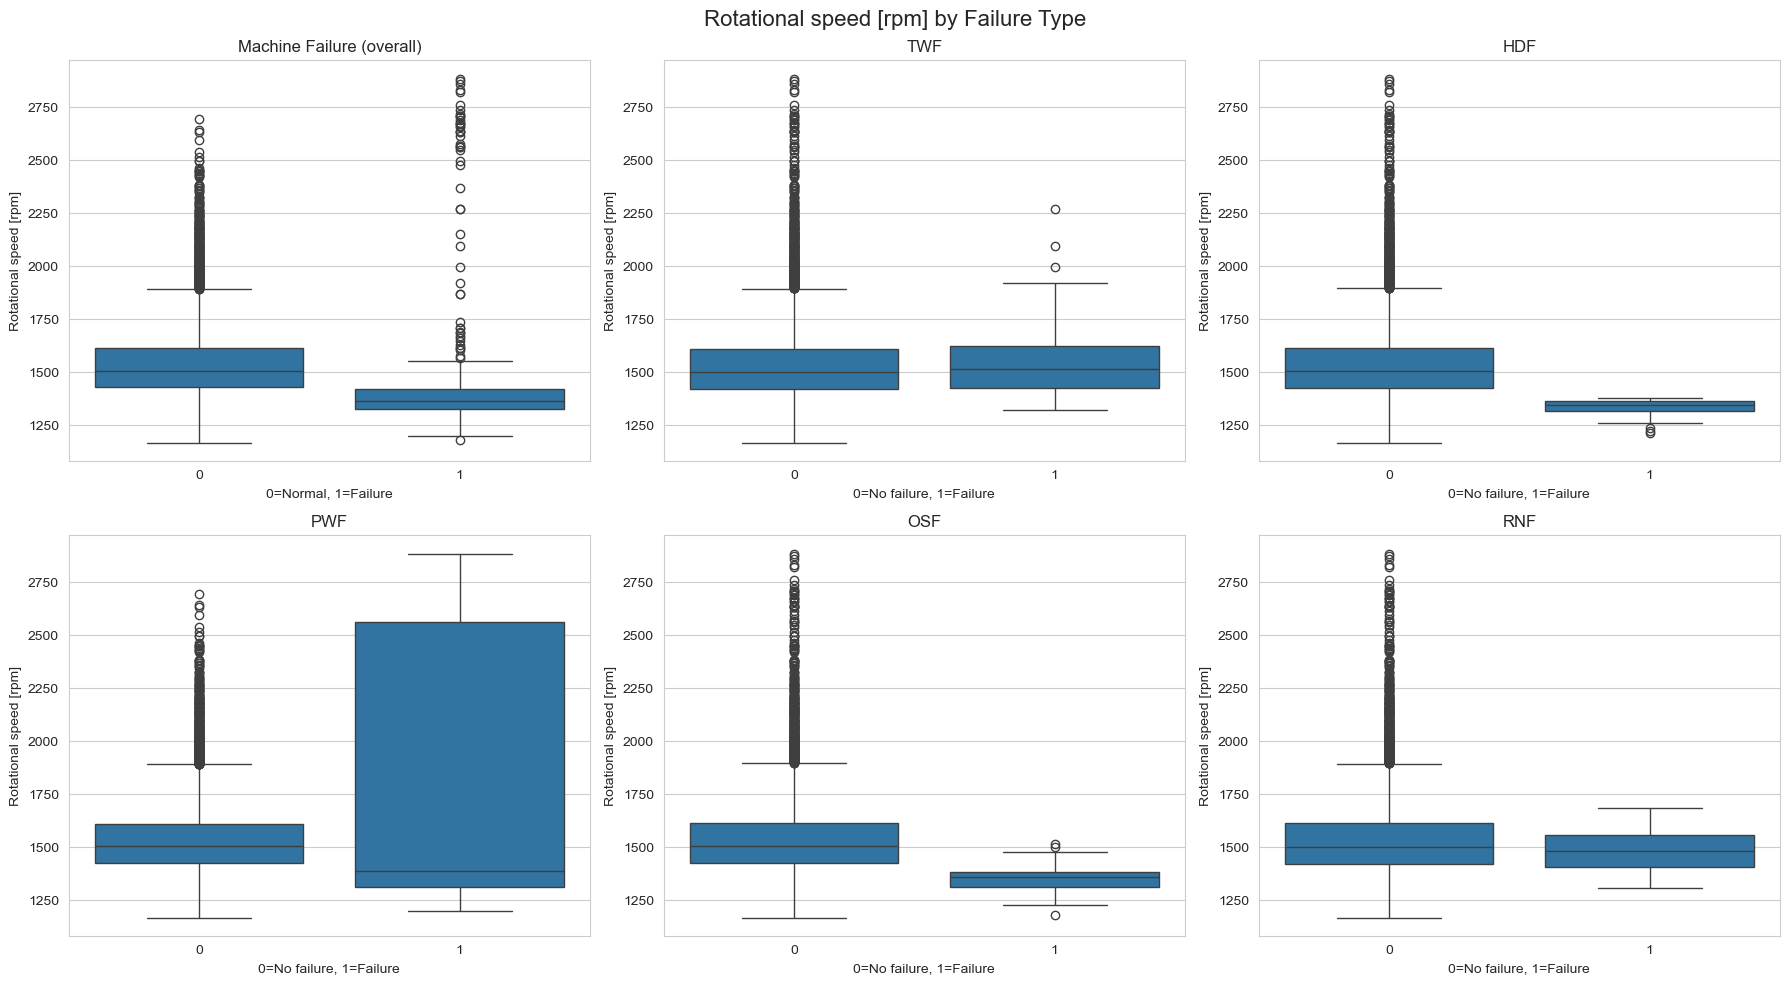

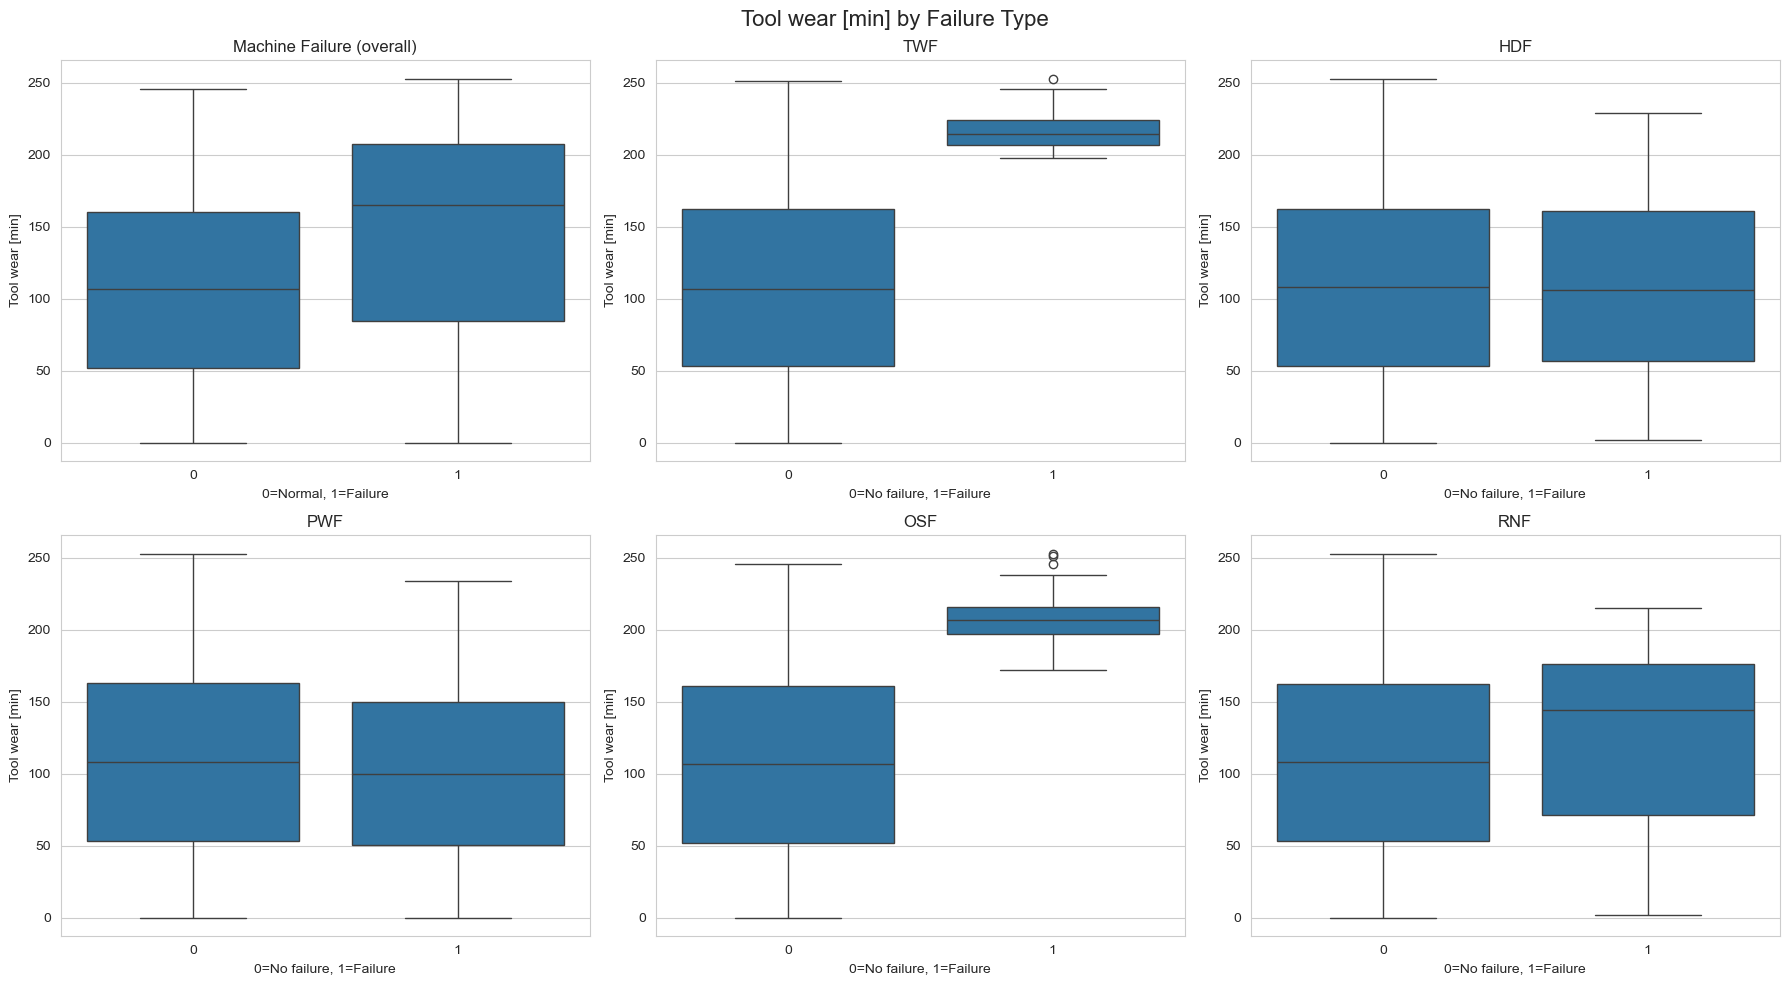

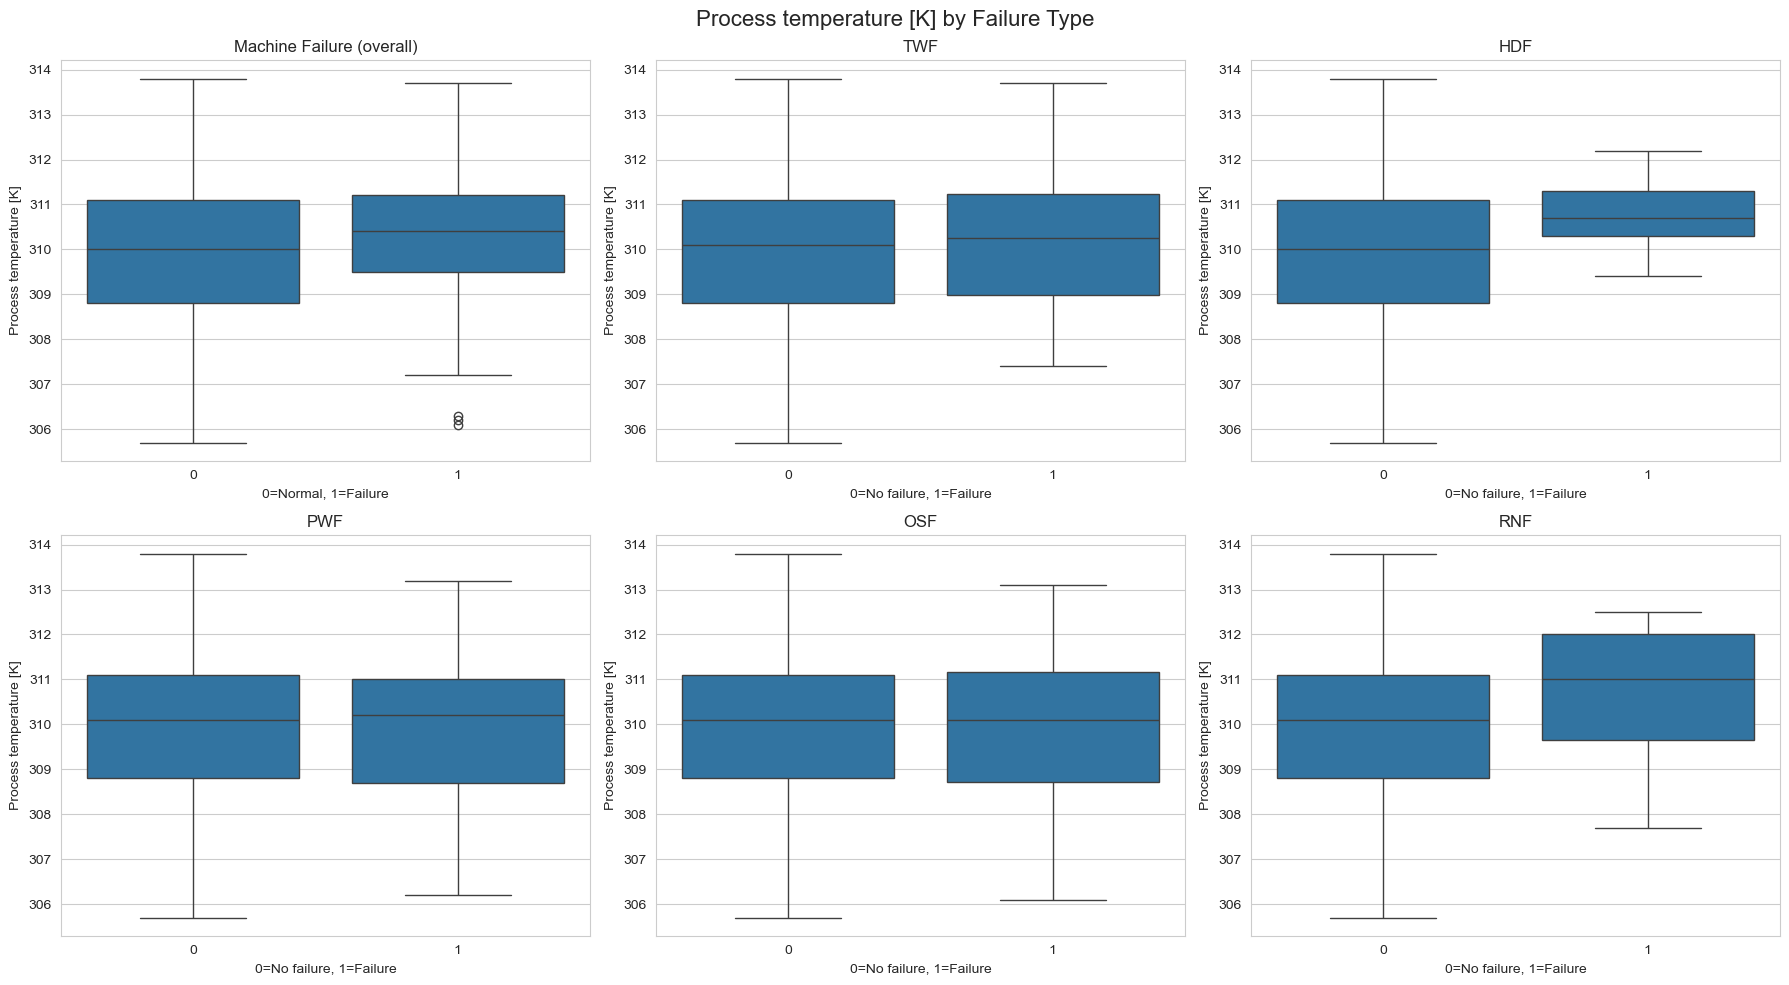

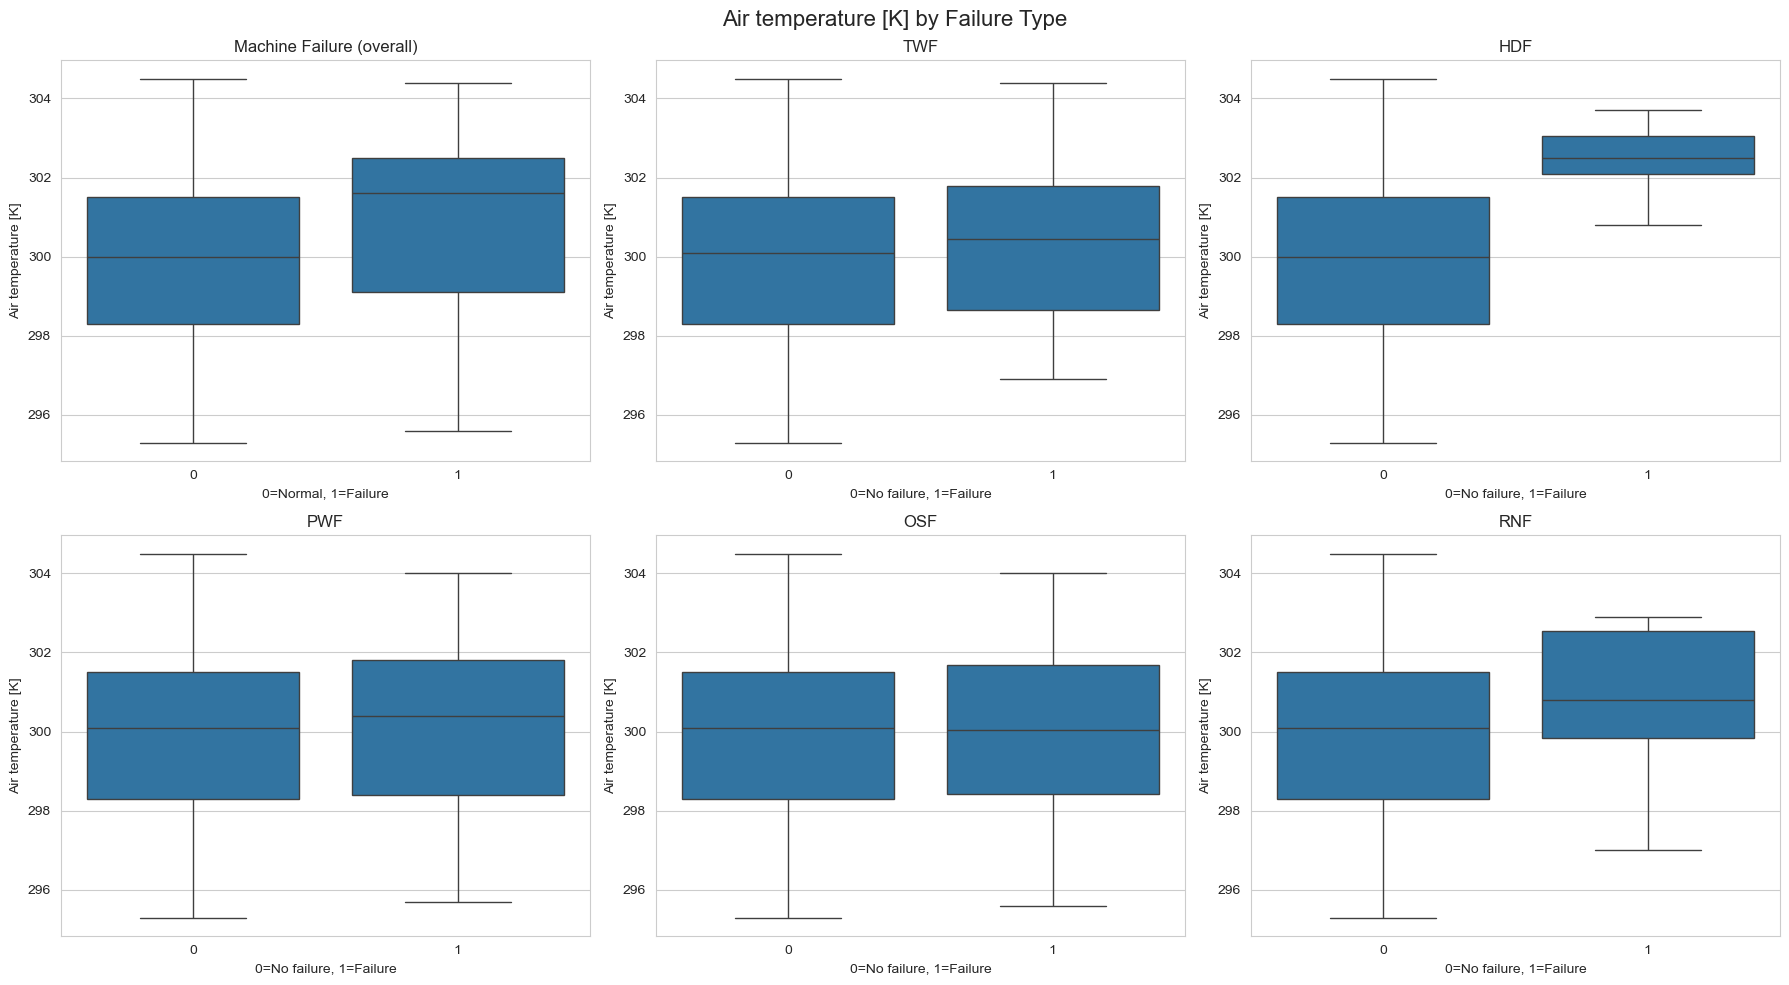

In [8]:
key_features = ['Torque [Nm]', 'Rotational speed [rpm]', 
                'Tool wear [min]', 'Process temperature [K]',
                'Air temperature [K]']

for feature in key_features:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{feature} by Failure Type', fontsize=16)
    
    sns.boxplot(ax=axes[0,0], data=df, x='Machine failure', y=feature)
    axes[0,0].set_title('Machine Failure (overall)')
    axes[0,0].set_xlabel('0=Normal, 1=Failure')
    
    for i, ft in enumerate(failure_types):
        row = (i+1) // 3
        col = (i+1) % 3
        sns.boxplot(ax=axes[row, col], data=df, x=ft, y=feature)
        axes[row, col].set_title(ft)
        axes[row, col].set_xlabel('0=No failure, 1=Failure')
    
    plt.tight_layout()
    plt.show()

## 4. Feature Engineering

New features are created based on mechanical engineering principles:
- **Power_W**: mechanical power (P = τ × ω)
- **Temp_diff**: temperature difference between process and environment
- **Energy**: cumulative energy input (Power × Tool wear time)
- **Torque_x_Toolwear**: combined mechanical stress indicator
- **RPM_x_Toolwear**: wear rate due to rotational speed
- **Wear_at_Low_Speed**: tool wear weighted by low speed (more dangerous)
- **Type_encoded**: machine quality grade (L=0, M=1, H=2)

In [9]:
# Base features and target
base_features = ['Air temperature [K]', 'Process temperature [K]',
                 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

X = df[base_features].copy()
y = df['Machine failure']

# Rename columns for XGBoost compatibility
X.columns = ['Air_temp_K', 'Process_temp_K', 
             'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min']

# Engineering-based features
X['Power_W'] = X['Torque_Nm'] * (X['Rotational_speed_rpm'] * 2 * np.pi / 60)
X['Temp_diff'] = X['Process_temp_K'] - X['Air_temp_K']
X['Energy'] = X['Power_W'] * X['Tool_wear_min']
X['Torque_x_Toolwear'] = X['Torque_Nm'] * X['Tool_wear_min']
X['RPM_x_Toolwear'] = X['Rotational_speed_rpm'] * X['Tool_wear_min']
X['Wear_at_Low_Speed'] = X['Tool_wear_min'] * (10000 / X['Rotational_speed_rpm'])

# Machine quality grade
le = LabelEncoder()
X['Type_encoded'] = le.fit_transform(df['Type'])

print(f"Total features: {X.shape[1]}")
print(f"Feature list: {X.columns.tolist()}")

# Correlation of new features with Machine failure
new_features_corr = X.copy()
new_features_corr['Machine failure'] = y
print("\nCorrelation of engineered features with Machine failure:")
print(new_features_corr.corr()['Machine failure'].sort_values(ascending=False))

Total features: 12
Feature list: ['Air_temp_K', 'Process_temp_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Power_W', 'Temp_diff', 'Energy', 'Torque_x_Toolwear', 'RPM_x_Toolwear', 'Wear_at_Low_Speed', 'Type_encoded']

Correlation of engineered features with Machine failure:
Machine failure         1.000000
Torque_Nm               0.191321
Torque_x_Toolwear       0.190427
Power_W                 0.176039
Energy                  0.164205
Wear_at_Low_Speed       0.130213
Tool_wear_min           0.105448
RPM_x_Toolwear          0.085725
Air_temp_K              0.082556
Process_temp_K          0.035946
Type_encoded           -0.005152
Rotational_speed_rpm   -0.044188
Temp_diff              -0.111676
Name: Machine failure, dtype: float64


## 5. Model Training & Evaluation

### 5.1 Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")
print(f"\nFailure rate in train: {y_train.mean():.1%}")
print(f"Failure rate in test:  {y_test.mean():.1%}")

# Class imbalance ratio — used for scale_pos_weight in XGBoost
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance ratio: {scale:.1f}x")

Train set: 8000 samples
Test set:  2000 samples

Failure rate in train: 3.4%
Failure rate in test:  3.4%

Class imbalance ratio: 28.5x


### 5.2 Baseline Random Forest

A baseline Random Forest model is trained first to establish a performance benchmark.

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_proba_rf >= 0.35).astype(int)

print("Baseline Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

Baseline Random Forest Results:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.89      0.84      0.86        68

    accuracy                           0.99      2000
   macro avg       0.94      0.92      0.93      2000
weighted avg       0.99      0.99      0.99      2000



### 5.3 XGBoost + Optuna Hyperparameter Tuning

XGBoost is selected as the final model due to its superior performance on tabular data.
Optuna was used for systematic hyperparameter optimization over 50 trials, 
maximizing F1-score on the minority class (Failure).
max_depth is constrained to ≤6 to prevent overfitting.

The optimal parameters found by Optuna are used directly below
to ensure reproducibility of results.

In [12]:
# Optuna was used to find optimal hyperparameters (50 trials, maximizing F1-score)
# Best parameters found:
best_params = {
    'n_estimators': 328,
    'max_depth': 5,
    'learning_rate': 0.19319689982789898,
    'subsample': 0.6263147505489439,
    'colsample_bytree': 0.8773375292691852,
    'min_child_weight': 1
}

print("Best parameters found by Optuna:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

Best parameters found by Optuna:
  n_estimators: 328
  max_depth: 5
  learning_rate: 0.19319689982789898
  subsample: 0.6263147505489439
  colsample_bytree: 0.8773375292691852
  min_child_weight: 1


### 5.4 Final Model Evaluation

Final Model Results:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.88      0.84      0.86        68

    accuracy                           0.99      2000
   macro avg       0.94      0.92      0.93      2000
weighted avg       0.99      0.99      0.99      2000



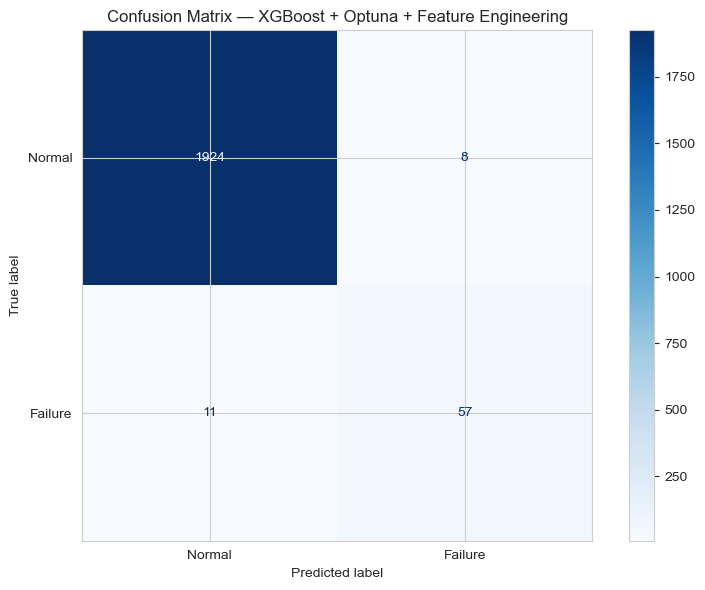


True Negatives  (Correct Normal):   1924
False Positives (False Alarms):     8
False Negatives (Missed Failures):  11
True Positives  (Correct Failures): 57


In [13]:
best_model = XGBClassifier(
    **best_params,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
best_model.fit(X_train, y_train)

y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.35).astype(int)

print("Final Model Results:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Normal', 'Failure'],
    cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix — XGBoost + Optuna + Feature Engineering')
plt.tight_layout()
plt.show()

tn = ((y_test == 0) & (y_pred == 0)).sum()
fp = ((y_test == 0) & (y_pred == 1)).sum()
fn = ((y_test == 1) & (y_pred == 0)).sum()
tp = ((y_test == 1) & (y_pred == 1)).sum()

print(f"\nTrue Negatives  (Correct Normal):   {tn}")
print(f"False Positives (False Alarms):     {fp}")
print(f"False Negatives (Missed Failures):  {fn}")
print(f"True Positives  (Correct Failures): {tp}")

## 6. SHAP Explainability

SHAP (SHapley Additive exPlanations) is used to explain model predictions.
It quantifies the contribution of each feature to the final decision,
making the model interpretable for non-technical stakeholders.

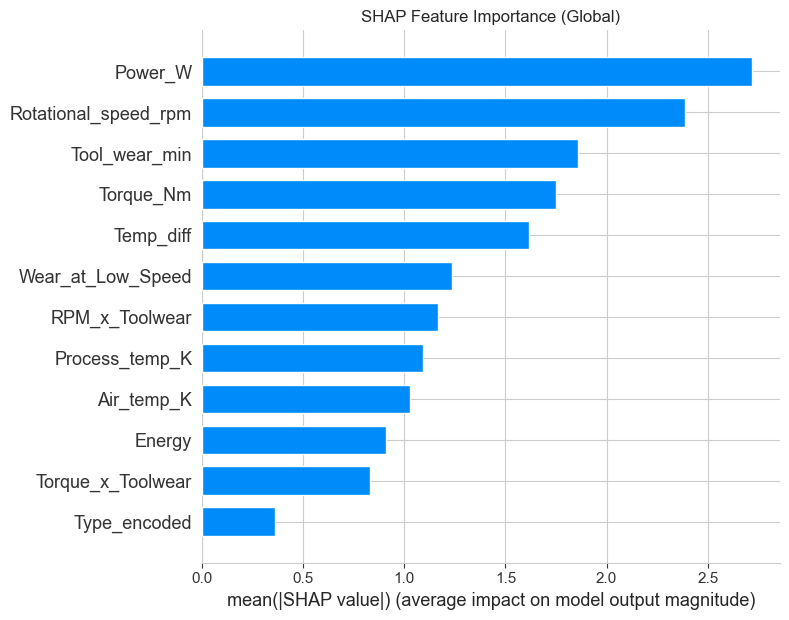

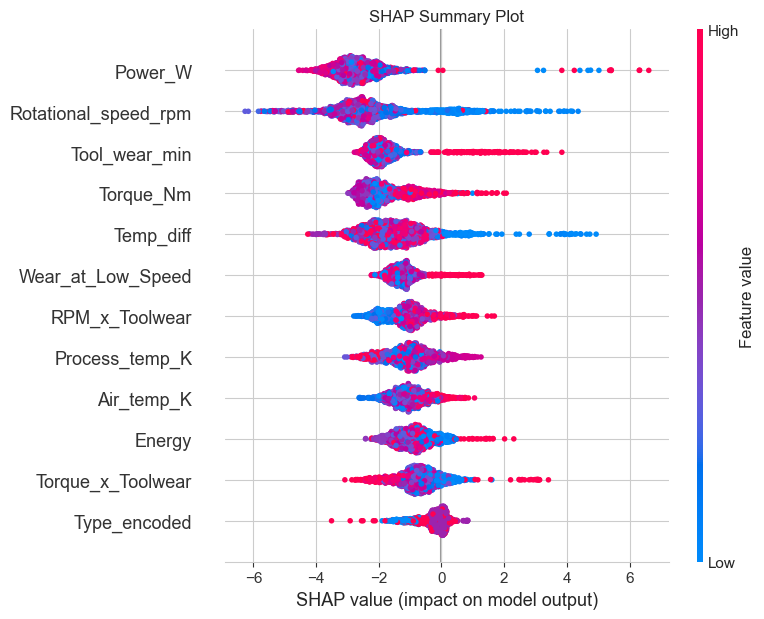

In [14]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Global Feature Importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Global)")
plt.tight_layout()
plt.show()

# Beeswarm plot — shows direction of impact
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

Observation #17
True label: 1 (0=Normal, 1=Failure)
Prediction: 1
Failure probability: 98.8%

Feature values:
Air_temp_K                 303.700000
Process_temp_K             312.100000
Rotational_speed_rpm      1363.000000
Torque_Nm                   51.800000
Tool_wear_min               90.000000
Power_W                   7393.570759
Temp_diff                    8.400000
Energy                  665421.368275
Torque_x_Toolwear         4662.000000
RPM_x_Toolwear          122670.000000
Wear_at_Low_Speed          660.308144
Type_encoded                 1.000000
Name: 4851, dtype: float64


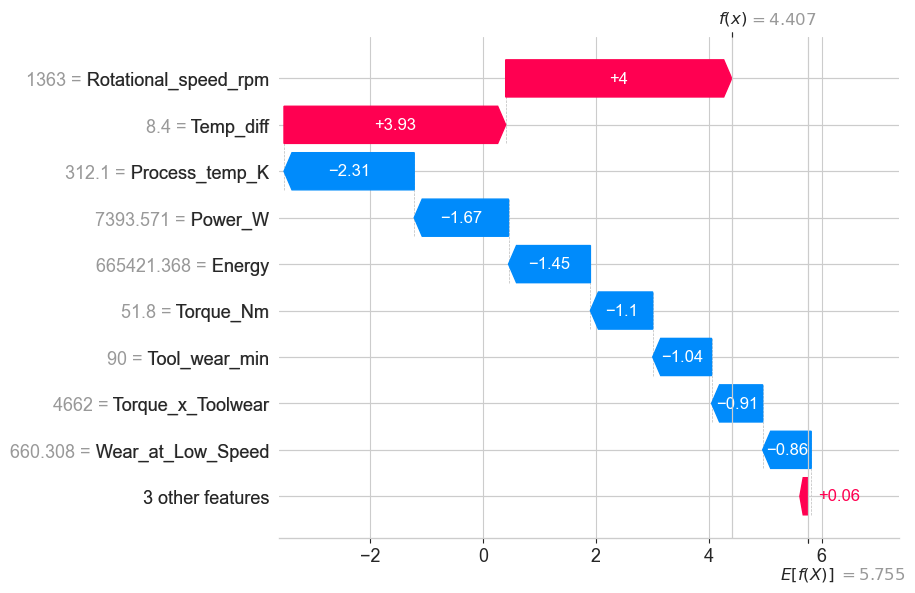

In [15]:
# Local explanation — single prediction analysis
# Find first correctly predicted failure
failure_indices = np.where(y_pred == 1)[0]
idx = failure_indices[0]

print(f"Observation #{idx}")
print(f"True label: {y_test.iloc[idx]} (0=Normal, 1=Failure)")
print(f"Prediction: {y_pred[idx]}")
print(f"Failure probability: {y_proba[idx]:.1%}")
print(f"\nFeature values:")
print(X_test.iloc[idx])

# Waterfall plot — shows how each feature contributed to this prediction
shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx],
    feature_names=X_test.columns.tolist()
))

## 7. Results & Limitations

### Results Summary
| Model | Precision (Failure) | Recall (Failure) | F1 (Failure) |
|-------|--------------------|--------------------|--------------|
| Baseline Random Forest | 0.90 | 0.63 | 0.74 |
| RF + Threshold Tuning | 0.75 | 0.75 | 0.75 |
| XGBoost + Optuna + Feature Engineering | 0.88 | 0.84 | 0.86 |

### Key Findings
- Feature engineering had the highest impact on model performance
- Torque and Rotational Speed are the most important predictors
- The optimal decision threshold (0.35) was found via Precision-Recall curve analysis
- 8 false alarms and 11 missed failures out of 2,000 test observations

### Limitations
- The AI4I 2020 dataset is synthetically generated, meaning failure thresholds
  are built into the data by design. This causes the model to learn sharp
  decision boundaries that may not generalize to real-world sensor data.
- The optimal threshold (0.35) assumes equal cost for false alarms and missed failures.
  In practice, the threshold should be adjusted based on:
  - Cost of unplanned downtime (missed failure)
  - Cost of unnecessary maintenance (false alarm)
- With only 339 failure cases out of 10,000, the model has limited examples
  to learn from for the minority class.

## 8. Save Model

In [16]:
os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/xgb_model.pkl')
joblib.dump(X.columns.tolist(), 'models/feature_names.pkl')
joblib.dump(le, 'models/label_encoder.pkl')
joblib.dump(0.35, 'models/threshold.pkl')

print("✅ Model saved successfully!")
print("   - models/xgb_model.pkl")
print("   - models/feature_names.pkl")
print("   - models/label_encoder.pkl")
print("   - models/threshold.pkl")

✅ Model saved successfully!
   - models/xgb_model.pkl
   - models/feature_names.pkl
   - models/label_encoder.pkl
   - models/threshold.pkl
